## Section 3 (Notes)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
x0 = 1.000
x1 = 0.999
x0 - x1

0.0010000000000000009

### Representing real numbers

Python employs what are known as double-precision floating point numbers, also called doubles; their storage uses 64 bits in total. Doubles can represent:
$$ \pm 4.9\times10^{-324} \leftrightarrow \pm 1.8\times 10^{308} $$

In [5]:
# we can represent
print(4.9e-324)

# but not 
print(4.9e-325)

5e-324
0.0


In [6]:
# we can represent
print(1.8e307)

# but not 
print(1.8e308)

1.8e+307
inf


In [7]:
1.7e308

1.7e+308

#### Overflow

In [8]:
# exhibits overflow

large = 2.**1021
for i in range(3):
    large *= 2
    print(i, large)

0 4.49423283715579e+307
1 8.98846567431158e+307
2 inf


In [9]:
print(8.98846567431158e+307*1.999999999999999)
print(8.98846567431158e+307*2.)

1.797693134862315e+308
inf


#### Underflow

In [10]:
from math import sqrt

def f(x, nmax=100):
    for i in range(nmax):
        x = sqrt(x)
    for i in range(nmax):
        x = x**2
    return x

for xin in (5., 0.5):
    xout = f(xin)
    print(xin, xout)

5.0 1.0
0.5 0.0


In [27]:
for i in range(100):
    x = x**2
    print(x)

0.9999999999999998
0.9999999999999996
0.9999999999999991
0.9999999999999982
0.9999999999999964
0.9999999999999929
0.9999999999999858
0.9999999999999716
0.9999999999999432
0.9999999999998863
0.9999999999997726
0.9999999999995453
0.9999999999990905
0.999999999998181
0.999999999996362
0.999999999992724
0.9999999999854481
0.9999999999708962
0.9999999999417923
0.9999999998835847
0.9999999997671694
0.9999999995343387
0.9999999990686774
0.9999999981373549
0.9999999962747097
0.9999999925494194
0.9999999850988388
0.9999999701976778
0.9999999403953566
0.9999998807907167
0.9999997615814475
0.9999995231629519
0.9999990463261312
0.999998092653172
0.9999961853099819
0.9999923706345157
0.9999847413272387
0.9999694828873045
0.9999389667059031
0.9998779371368692
0.999755889173081
0.9995118379362579
0.9990239141747163
0.9980487810929708
0.9961013694411648
0.9922179382025639
0.9844964368909469
0.9692332342509702
0.939413062376596
0.8824969017637744
0.7788007816226609
0.6065306574560675
0.3678794384340895

In [26]:
x = 0.5
for i in range(100):
    x = sqrt(x)
    print(x)

0.7071067811865476
0.8408964152537146
0.9170040432046712
0.9576032806985736
0.9785720620877001
0.9892280131939755
0.9945994234836332
0.9972960560854701
0.9986471128909702
0.9993233275026507
0.9996616064962437
0.9998307889319291
0.9999153908866135
0.9999576945484312
0.999978847050492
0.9999894234693145
0.9999947117206743
0.9999973558568415
0.9999986779275468
0.999999338963555
0.9999996694817229
0.9999998347408479
0.9999999173704205
0.9999999586852094
0.9999999793426045
0.9999999896713022
0.999999994835651
0.9999999974178255
0.9999999987089128
0.9999999993544564
0.9999999996772282
0.9999999998386141
0.999999999919307
0.9999999999596535
0.9999999999798267
0.9999999999899133
0.9999999999949566
0.9999999999974782
0.9999999999987391
0.9999999999993695
0.9999999999996847
0.9999999999998423
0.9999999999999212
0.9999999999999606
0.9999999999999802
0.9999999999999901
0.999999999999995
0.9999999999999974
0.9999999999999987
0.9999999999999993
0.9999999999999997
0.9999999999999998
0.999999999999999

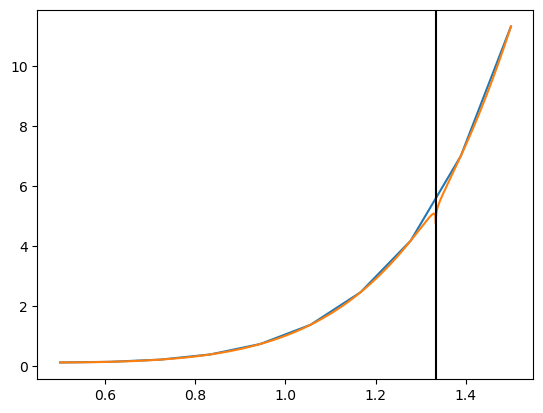

In [12]:
import numpy as np

def f(x):
    return x**6 + 0.1*np.log(np.abs(1+3*(1-x)))

xlist = np.linspace(.5, 1.5, 10)
xlistmore = np.linspace(.5, 1.5, 10000)

plt.plot(xlist, f(xlist))
plt.plot(xlistmore, f(xlistmore))
plt.axvline(4/3, c='k')
# plt.xlim(1.333, 1.3335)

In [13]:
xtilde = 1234567891234567.0
ytilde = 1234567891234566.0

xtilde**2 - ytilde**2 # this has catastrophic cancellation!

2533274790395904.0

In [14]:
int(xtilde)**2 - int(ytilde)**2 # this is exact; notice we converted to int first

2469135782469133

In [15]:
(int(xtilde) - int(ytilde))*(int(xtilde) + int(ytilde)) # this trick tells us that converting to ints is good

2469135782469133

#### Machine precision

In [16]:
small = 1/2**50
for i in range(3):
    small /= 2
    print(i, 1 + small, small)

0 1.0000000000000004 4.440892098500626e-16
1 1.0000000000000002 2.220446049250313e-16
2 1.0 1.1102230246251565e-16


In [17]:
print(1. + 2.3e-16)
print(1. + 1.6e-16)
print(1. + 1.12e-16)
print(1. + 1.1e-16)

1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0


In [18]:
0.5e-16+0.5

0.5

In [19]:
def mean(xlist):
    mean = 0
    n = len(xlist)
    for x in xlist:
        mean += x
    return mean/n

def stdDev_1pass(xlist):
    mu = mean(xlist)
    n = len(xlist)
    sum = 0
    for x in xlist:
        sum += (x - mu)**2
    return sum/n

In [20]:
x1list = np.arange(0., 0.1, 0.01)
# x2list = 
x1list

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09])

In [21]:
xt = 0.1 + 0.2
yt = 0.3
epsilon = 1.e-12
abs(xt-yt) < epsilon

True

In [22]:
xt = 12345678912.345
yt = 12345678912.346
epsilon = 1.e-12
abs(xt-yt) < epsilon

def findmax(x,y):
    return max(abs(x),abs(y))

abs(xt-yt)/findmax(xt,yt) < epsilon


True

#### Plotting

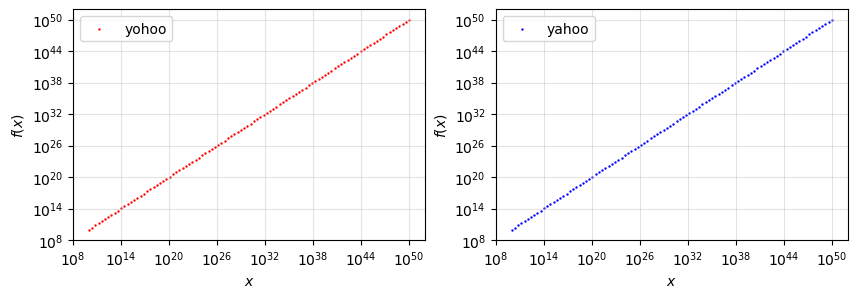

In [25]:
xlist = np.logspace(10, 50, 100)
ylist = xlist
ylist2 = xlist**2

fig, axs = plt.subplots(1,2, figsize=(10,3))
axs[0].scatter(xlist, ylist, s=0.5, c='r', label='yohoo')
axs[1].scatter(xlist, ylist, s=0.5, c='b', label='yahoo')

for ax in axs:
    ax.grid(True, alpha=0.35)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$f(x)$')
    ax.legend()
    ax.set_xscale('log')
    ax.set_yscale('log')
plt.show()